# 01 - Explore cleaned data

Sanity-check the tables produced by `src.data.load_data` before building features on top of them: shapes, date coverage, missingness, and class balance of fight outcomes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

fighters = pd.read_csv('../data/processed/fighters.csv', parse_dates=['dob'])
fights = pd.read_csv('../data/processed/fights.csv', parse_dates=['event_date'])
round_stats = pd.read_csv('../data/processed/round_stats.csv')

print('fighters:', fighters.shape)
print('fights:', fights.shape)
print('round_stats:', round_stats.shape)

fighters: (4573, 8)
fights: (8784, 18)
round_stats: (41344, 30)


## Date coverage and fights per year

date range: 1994-03-11 to 2026-07-18


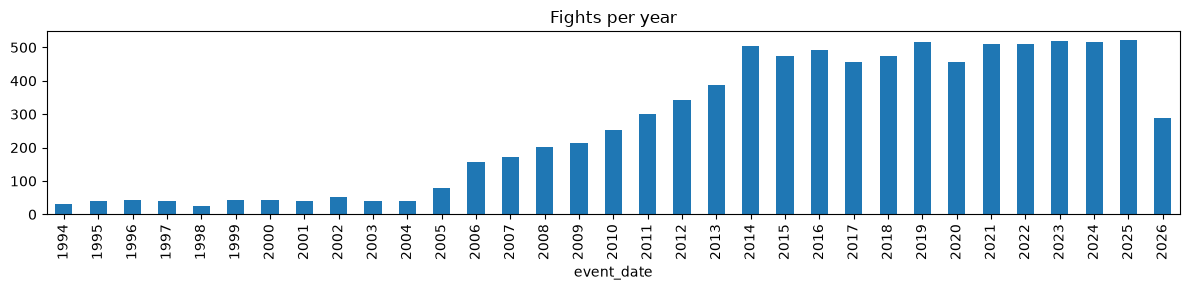

In [2]:
print('date range:', fights['event_date'].min().date(), 'to', fights['event_date'].max().date())
fights['event_date'].dt.year.value_counts().sort_index().plot(kind='bar', figsize=(12, 3), title='Fights per year')
plt.tight_layout()
plt.show()

## Outcome distribution (win/loss/draw/no-contest)

In [3]:
import numpy as np
outcome = np.select(
    [fights['is_no_contest'], fights['is_draw']],
    ['no_contest', 'draw'],
    default='decided',
)
pd.Series(outcome).value_counts()

decided       8629
no_contest      90
draw            65
Name: count, dtype: int64

## Missingness in fighter physical attributes

In [4]:
(fighters[['height_in', 'reach_in', 'weight_lbs', 'stance', 'dob']].isna().mean() * 100).round(1)

height_in     10.1
reach_in      45.6
weight_lbs     1.9
stance        21.3
dob           16.9
dtype: float64

## Weight class distribution

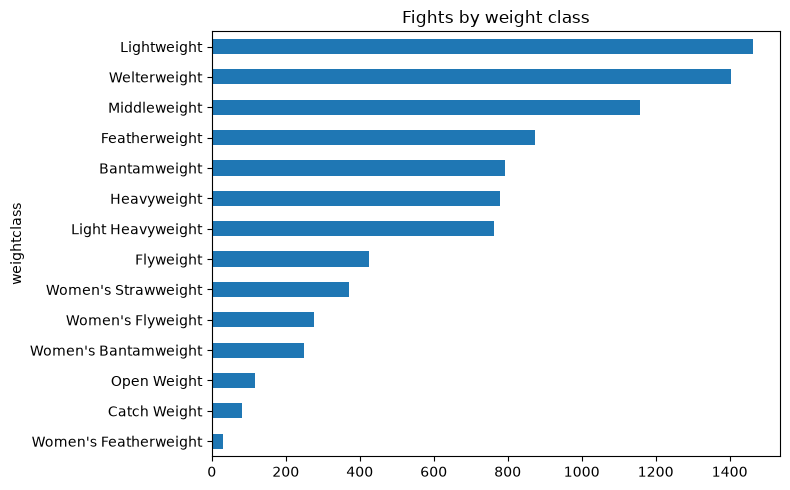

In [5]:
fights['weightclass'].value_counts().head(15).plot(kind='barh', figsize=(8, 5))
plt.gca().invert_yaxis()
plt.title('Fights by weight class')
plt.tight_layout()
plt.show()

## Known limitation: duplicate fighter names

A handful of UFC fighters share the exact same name (e.g. two different people named 'Bruno Silva'). `load_data.py` deliberately leaves these unmatched rather than risk mixing two people's records together -- this affects well under 1% of fighter slots across all fights.

In [6]:
dupe_names = fighters['name'].value_counts()
dupe_names = dupe_names[dupe_names > 1]
print(f'{len(dupe_names)} names shared by multiple fighters:')
dupe_names

8 names shared by multiple fighters:


name
Mike Davis           2
Anthony Figueroa     2
Joey Gomez           2
Tony Johnson         2
Michael McDonald     2
Jean Silva           2
Bruno Silva          2
Victor Valenzuela    2
Name: count, dtype: int64